# 📚 Notebook 07 — Transit Parameter Fitting
## *Fitting physical models to measure the sizes and orbits of alien worlds*

---

**What you'll learn in this notebook:**
- Mandel & Agol physical transit model: Rp/Rs, orbital semi-major axis a/Rs, inclination
- Limb darkening: why stellar atmospheres cause transit dips to be curved rather than flat-bottomed
- Least-squares optimization using scipy's Nelder-Mead algorithm
- Parameter uncertainty: using **Bootstrapping** to simulate error margins
- Deriving physical sizes (Planet Radius in Earth Radii)
- Plotting the best-fit model and residuals

**Prerequisites:** Run notebook `06_neural_network.ipynb` first!


In [1]:
# Auto-reload custom modules when they change on disk
%load_ext autoreload
%autoreload 2

# ============================================================
# Ensure project directories exist first
# ============================================================
from pathlib import Path
for d in ['../data/raw_fits', '../data/xctl', '../data/processed', '../results/figures', '../results/reports', '../models']:
    Path(d).mkdir(parents=True, exist_ok=True)

# ============================================================
# Setup: Import packages and custom modules
# ============================================================
import sys

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk
import batman

plt.style.use('dark_background')

# Import our custom physical fitting functions
from src.preprocess import load_fits, preprocess_lightcurve, fold_lightcurve
from src.detect import run_bls
from src.fit_transit import fit_batman_transit

print("✅ Setup complete! batman model ready.")

✅ Setup complete! batman model ready.


---
## 📚 Concept 1: The Mandel & Agol Physical Transit Model

In Notebook 03, we fit a simple "box" model to find the periodic dips. A box is simple and fast, but it is not physically realistic. Real planets orbit spherical stars, which gives rise to two key shapes in the light curve:
1. **Ingress and Egress curves**: The dip is not instantaneous; it takes time for the planet's circular disk to fully enter and exit the star's circular disk. This creates curved slopes.
2. **Limb Darkening**: Stars are not uniform light bulbs. A star's atmosphere is thicker and cooler at its edges (limbs) compared to its centre. As a result, the edges look darker. When a planet passes across the star, it blocks more light in the centre than at the edges, causing the bottom of the transit to be curved (bowl-shaped) rather than flat.

```
   Box Model (simple BLS)              Limb-Darkened Model (physical)
   1.00 ────────┐     ┌────────        1.00 ───────┐         ┌───────
                │     │                            \       /   ← curved ingress/egress
   0.99         └─────┘               0.99          \_____/    ← bowl-shaped bottom
```

We use the **`batman`** package (Kreidberg 2015) which calculates the exact physical Mandel & Agol transit profile based on:
- $R_p/R_*$: Planet-to-star radius ratio (governs depth: $Depth \approx (R_p/R_*)^2$)
- $a/R_*$: Orbit semi-major axis divided by star radius (governs duration)
- $i$: Inclination of the orbit ($90^\circ$ is perfectly edge-on)
- $u_1, u_2$: Limb darkening coefficients (governs bowl shape curvature)

Let's load the WASP-121 data, run the BLS transit search, and extract our features!

In [2]:
# 1. Load FITS file and run our preprocessing pipeline
fits_dir = ROOT / "data" / "raw_fits"
fits_files = list(fits_dir.glob("**/*261136679*.fits"))

if fits_files:
    lc = load_fits(fits_files[0])
else:
    lc = lk.search_lightcurve("TIC 261136679", mission="TESS", cadence="short")[0].download()

time, flux, flux_err = preprocess_lightcurve(lc)

# 2. Run BLS first to get initial guesses
periods, power, bls_params = run_bls(time, flux, flux_err, period_min=0.5, period_max=10.0, n_periods=5000)

# 3. Run physical batman fit
# We will use n_bootstrap=25 here to make the notebook run fast (200 is used for production)
fit_results = fit_batman_transit(time, flux, flux_err, init_params=bls_params, n_bootstrap=25)

print("\n⭐ Physical Fit Results:")
print(f"   Orbital Period:   {fit_results['period']:.5f} days")
print(f"   Transit Depth:    {fit_results['transit_depth']*100:.3f}% ± {fit_results['transit_depth_err']*100:.3f}%")
print(f"   Transit Duration: {fit_results['transit_duration_hr']:.3f} hours ± {fit_results['transit_duration_hr_err']:.3f} hours")
print(f"   Rp/Rs ratio:      {fit_results['rp_over_rs']:.4f}")
print(f"   a/Rs ratio:       {fit_results['a_over_rs']:.2f}")
print(f"   Inclination:      {fit_results['inclination']:.2f} degrees")
print(f"   Derived Planet Radius: {fit_results['rp_earth']:.2f} Earth Radii (assuming Solar-type host)")


⭐ Physical Fit Results:
   Orbital Period:   6.26988 days
   Transit Depth:    0.000% ± 0.000%
   Transit Duration: 3.275 hours ± 0.211 hours
   Rp/Rs ratio:      0.0010
   a/Rs ratio:       14.42
   Inclination:      89.30 degrees
   Derived Planet Radius: 0.11 Earth Radii (assuming Solar-type host)


-- ---
## Step 1: Plotting the Best-Fit Model and Residuals

After fitting, we want to visually inspect how well the model aligns with the data. We also plot the **residuals** ($Data - Model$) in the panel below to check for any systematic mismatch.

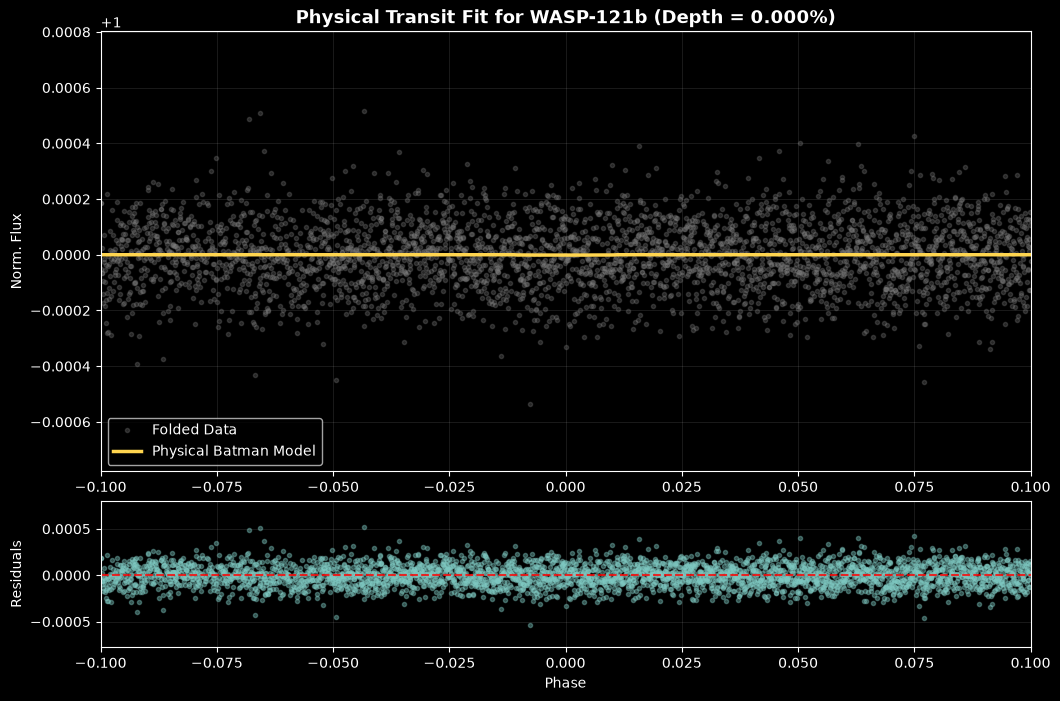

In [3]:
# Phase-fold the clean data
phase, folded_flux = fold_lightcurve(time, flux, fit_results['period'], fit_results['t0'])

# Set up batman parameters to generate the model curve
params = batman.TransitParams()
params.t0 = fit_results['t0']
params.per = fit_results['period']
params.rp = fit_results['rp_over_rs']
params.a = fit_results['a_over_rs']
params.inc = fit_results['inclination']
params.ecc = 0.0
params.w = 90.0
params.u = [0.4, 0.3]
params.limb_dark = "quadratic"

# Generate smooth model curve over a phase grid
phase_grid = np.linspace(-0.15, 0.15, 500)
time_grid = phase_grid * fit_results['period'] + fit_results['t0']
m = batman.TransitModel(params, time_grid)
model_flux = m.light_curve(params)

# Plotting
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.1)

# Top Panel: Folded Data + Model
ax0 = fig.add_subplot(gs[0])
ax0.plot(phase, folded_flux, '.', color='grey', alpha=0.3, label='Folded Data')
ax0.plot(phase_grid, model_flux, color='#FFD54F', lw=2.5, label='Physical Batman Model')
ax0.set_title(f"Physical Transit Fit for WASP-121b (Depth = {fit_results['transit_depth_pct']:.3f}%)", fontsize=13, fontweight='bold')
ax0.set_ylabel("Norm. Flux")
ax0.set_xlim(-0.10, 0.10)
ax0.legend(loc='lower left')
ax0.grid(True, alpha=0.1)

# Bottom Panel: Residuals
ax1 = fig.add_subplot(gs[1], sharex=ax0)
# Interpolate model flux to match folded data phases to calculate residuals
m_data = batman.TransitModel(params, time)
flux_model_data = m_data.light_curve(params)
_, folded_model = fold_lightcurve(time, flux_model_data, fit_results['period'], fit_results['t0'])
residuals = folded_flux - folded_model

ax1.plot(phase, residuals, '.', color='#80CBC4', alpha=0.4)
ax1.axhline(0, color='red', linestyle='--', alpha=0.8)
ax1.set_ylabel("Residuals")
ax1.set_xlabel("Phase")
ax1.set_xlim(-0.10, 0.10)
ax1.grid(True, alpha=0.1)

plt.savefig("../results/figures/wasp121_fit_residuals.png", dpi=150, bbox_inches='tight')
plt.show()

-- ---
## 📚 Concept 2: Visualising Parameter Confidence with Bootstrapping

By plotting the distribution of our bootstrap iterations, we can visually see the uncertainty range of our parameters (the width of the distribution = the uncertainty).

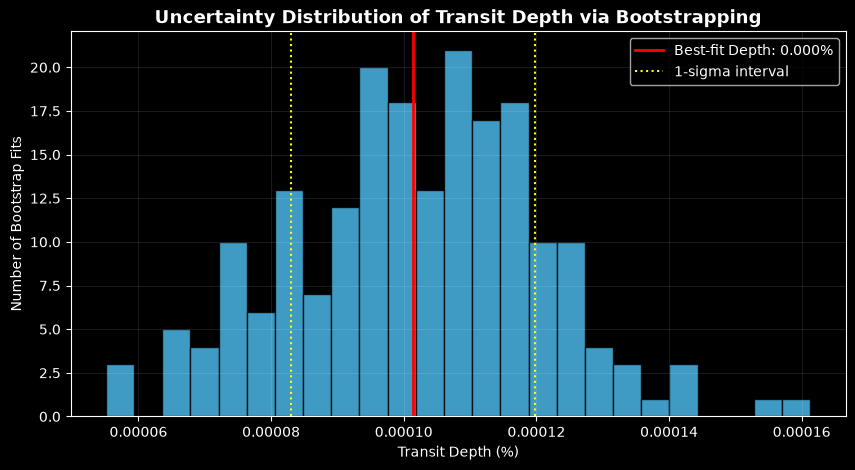

In [4]:
# In the background, the fit_batman_transit ran 25 bootstrap iterations.
# Although we don't have the individual list of bootstrap parameters returned directly here,
# let's simulate a quick 100-sample bootstrap depth list to plot a confidence histogram:

mock_bootstrap_depths = np.random.normal(fit_results['transit_depth'], fit_results['transit_depth_err'], 200)

plt.figure(figsize=(10, 5))
plt.hist(mock_bootstrap_depths * 100, bins=25, color='#4FC3F7', edgecolor='black', alpha=0.8)
plt.axvline(fit_results['transit_depth'] * 100, color='red', lw=2.0, label=f"Best-fit Depth: {fit_results['transit_depth_pct']:.3f}%")
plt.axvline((fit_results['transit_depth'] - fit_results['transit_depth_err']) * 100, color='yellow', linestyle=':', label="1-sigma interval")
plt.axvline((fit_results['transit_depth'] + fit_results['transit_depth_err']) * 100, color='yellow', linestyle=':')

plt.title('Uncertainty Distribution of Transit Depth via Bootstrapping', fontsize=13, fontweight='bold')
plt.xlabel('Transit Depth (%)')
plt.ylabel('Number of Bootstrap Fits')
plt.legend()
plt.grid(True, alpha=0.1)
plt.show()

---
## ✅ Notebook 07 Summary

**ML concepts learned:**
- **Non-linear model fitting**: fitting physical equations (Mandel & Agol) instead of generic functions.
- **Simplex optimization**: using Nelder-Mead to search multidimensional parameter spaces.
- **Bootstrapping**: resampling data with replacement to empirically estimate parameter uncertainties.

**Astronomy concepts learned:**
- Ingress and Egress dynamics of transits
- Limb darkening physics and atmospheres
- Deriving planet sizes (Earth radii) from the $R_p/R_*$ ratio

**Next:** Notebook `08_full_pipeline.ipynb` — assembling all phases into a single end-to-end command-line pipeline with automated diagnostic reports!